# **Consumer complaint classification**

# Executive Summary

This project automates the classification of consumer financial complaints using Natural Language Processing (NLP) and machine learning. By accurately identifying the product category associated with each complaint, the system enables faster routing to the appropriate department.

### Business Value
- Reduces manual effort required to triage complaints
- Improves response time and customer satisfaction
- Scales efficiently to thousands of complaints per week
- Enables data-driven insights into complaint trends


# Problem

- Each week the Consumer Financial Protection Bureau sends thousands
of consumers’ complaints about financial products and services to
companies for a response. Classify those consumer complaints into the
product category it belongs to using the description of the complaint.

- Incorrect routing of complaints increases resolution time and regulatory risk.

# Solution

The goal of the project is to classify the complaint into a specific product
category. Since it has multiple categories, it becomes a multiclass
classification that can be solved through many of the machine learning
algorithms.Once the algorithm is in place, whenever there is a new complaint,
we can easily categorize it and can then be redirected to the concerned
person. This will save a lot of time because we are minimizing the human
intervention to decide whom this complaint should go to.

### Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from sklearn.utils.class_weight import compute_class_weight  # for imbalance
import joblib  # for saving models
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

### Load Data

In [3]:
Data=pd.read_csv("consumer_complaints.csv",low_memory=False)

### Data Understanding
The dataset contains consumer complaints submitted to the CFPB along with
the associated financial product category. Only complaints with narratives
are used, as free-text descriptions are required for NLP modeling.

In [4]:
Data.head()

,date_received,product,sub_product,issue,sub_issue,consumer_complaint_narrative,company_public_response,company,state,zipcode,tags,consumer_consent_provided,submitted_via,date_sent_to_company,company_response_to_consumer,timely_response,consumer_disputed?,complaint_id
0,08/30/2013,Mortgage,Other mortgage,"Loan modification,collection,foreclosure",NaN,NaN,NaN,U.S. Bancorp,CA,95993,NaN,NaN,Referral,09/03/2013,Closed with explanation,Yes,Yes,511074
1,08/30/2013,Mortgage,Other mortgage,"Loan servicing, payments, escrow account",NaN,NaN,NaN,Wells Fargo & Company,CA,91104,NaN,NaN,Referral,09/03/2013,Closed with explanation,Yes,Yes,511080
2,08/30/2013,Credit reporting,NaN,Incorrect information on credit report,Account status,NaN,NaN,Wells Fargo & Company,NY,11764,NaN,NaN,Postal mail,09/18/2013,Closed with explanation,Yes,No,510473
3,08/30/2013,Student loan,Non-federal student loan,Repaying your loan,Repaying your loan,NaN,NaN,"Navient Solutions, Inc.",MD,21402,NaN,NaN,Email,08/30/2013,Closed with explanation,Yes,Yes,510326
4,08/30/2013,Debt collection,Credit card,False statements or representation,Attempted to collect wrong amount,NaN,NaN,Resurgent Capital Services L.P.,GA,30106,NaN,NaN,Web,08/30/2013,Closed with explanation,Yes,Yes,511067


In [5]:
Data.shape

(555957, 18)

In [6]:
Data = Data[['product', 'consumer_complaint_narrative']].dropna()
Data.drop_duplicates(inplace=True)

In [7]:
Data.isnull().sum()

product                         0
consumer_complaint_narrative    0
dtype: int64

In [8]:
Data.sample(10)

,product,consumer_complaint_narrative
249041,Consumer Loan,"At XX/XX/XXXX, I had a buyer for our RV and be..."
308343,Mortgage,I have reason to believe that my deaseased hus...
269555,Mortgage,I was illegally denied a loan mod with Bank of...
303282,Mortgage,I have received on XXXX/XXXX/2015 letter dated...
304770,Credit reporting,I belong to XXXX XXXX and check my status regu...
234373,Debt collection,AR Resources has called my business cell phone...
262334,Debt collection,XX/XX/XXXX I tried to cancel a gym membership ...
242421,Credit reporting,My credit report from Equifax falsely represen...
238836,Debt collection,I received a call from an anonymous number fro...
530936,Credit reporting,"FHA Loan-short sale, FHA requires that I am la..."


In [9]:
print(Data['product'].value_counts())

product
Debt collection            17136
Mortgage                   14910
Credit reporting           11873
Credit card                 7909
Bank account or service     5688
Consumer Loan               3669
Student loan                2121
Prepaid card                 859
Payday loan                  726
Money transfers              665
Other financial service      109
Name: count, dtype: int64


In [10]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
Data['category_id'] = encoder.fit_transform(Data['product'])
Data.head()

,product,consumer_complaint_narrative,category_id
190126,Debt collection,XXXX has claimed I owe them {$27.00} for XXXX ...,4
190135,Consumer Loan,Due to inconsistencies in the amount owed that...,1
190155,Mortgage,In XX/XX/XXXX my wages that I earned at my job...,6
190207,Mortgage,I have an open and current mortgage with Chase...,6
190208,Mortgage,XXXX was submitted XX/XX/XXXX. At the time I s...,6


In [11]:
# Check the distriution of complaints by category
Data.groupby('product').consumer_complaint_narrative.count()

product
Bank account or service     5688
Consumer Loan               3669
Credit card                 7909
Credit reporting           11873
Debt collection            17136
Money transfers              665
Mortgage                   14910
Other financial service      109
Payday loan                  726
Prepaid card                 859
Student loan                2121
Name: consumer_complaint_narrative, dtype: int64

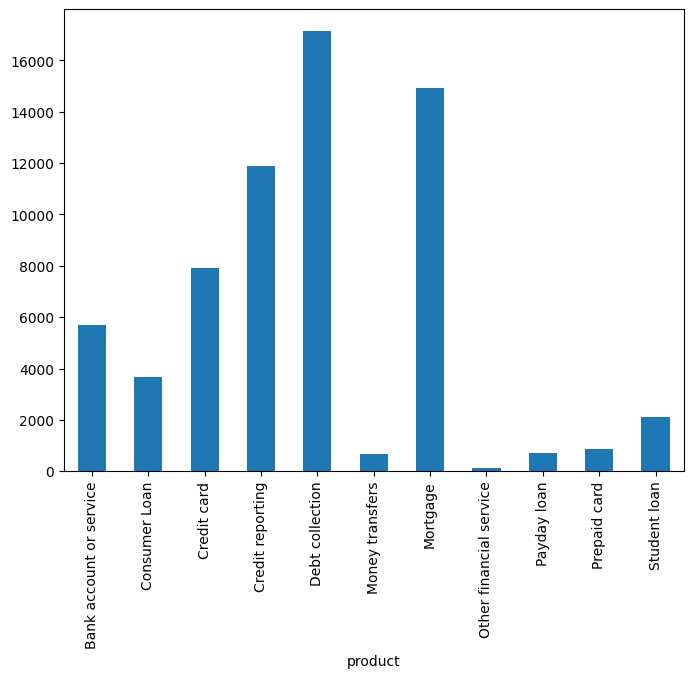

In [12]:
# Lets plot it and see
fig = plt.figure(figsize=(8,6))
Data.groupby('product').consumer_complaint_narrative.count().plot.bar(ylim=0)
plt.show()

### Text Preprocessing

In [13]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\d+', '<NUM>', text)  # replace numbers
    text = re.sub(r'[^a-zA-Z<NUM>]', ' ', text)  # keep letters and <NUM>
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return " ".join(tokens)

Data['cleaned_complaint'] = Data['consumer_complaint_narrative'].apply(clean_text)

[nltk_data] Downloading package stopwords to C:\Users\Mittal
[nltk_data]     Chauhan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Mittal
[nltk_data]     Chauhan\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


### Splitting the data

Data Leakage Prevention:
- To ensure unbiased evaluation, the TF-IDF vectorizer is fitted only on the training data and never on the full dataset.

In [14]:
# Features and labels
X = Data['cleaned_complaint']  # preprocessed complaint text
y = Data['category_id']  # already encoded

In [15]:
# Train-test split
train_x, valid_x, train_y, valid_y = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [16]:
tfidf_vect = TfidfVectorizer(
    ngram_range=(1,2), max_features=7000, min_df=5, analyzer='word'
)
tfidf_vect.fit(train_x)  
xtrain_tfidf = tfidf_vect.transform(train_x)
xvalid_tfidf = tfidf_vect.transform(valid_x)

In [17]:
train_y

276324     5
510959     6
290645     6
324349     6
505386     4
          ..
298213     6
500480     4
234035     0
218280    10
206235     6
Name: category_id, Length: 52532, dtype: int32

In [18]:
valid_y

301592    3
232202    2
295022    6
227300    6
521370    1
         ..
276992    4
210718    6
267707    2
258943    2
524394    6
Name: category_id, Length: 13133, dtype: int32

In [19]:
xtrain_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4069913 stored elements and shape (52532, 7000)>

In [20]:
model = LogisticRegression(
    multi_class='ovr',
    solver='liblinear',
    class_weight='balanced',
    max_iter=200,
    random_state=42
)
model.fit(xtrain_tfidf, train_y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'liblinear'
,max_iter,200
,multi_class,'ovr'


In [21]:
model

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'liblinear'
,max_iter,200
,multi_class,'ovr'


In [22]:
acc_lr = accuracy_score(model.predict(xvalid_tfidf),valid_y)
print ("Accuracy: ", acc_lr)

Accuracy:  0.8455798370517018


In [23]:
from sklearn.metrics import f1_score

preds = model.predict(xvalid_tfidf)
print("Weighted F1:", f1_score(valid_y, preds, average='weighted'))
print("Macro F1:", f1_score(valid_y, preds, average='macro'))

Weighted F1: 0.8463128875484308
Macro F1: 0.7349205714543601


In [24]:
print(classification_report(
    valid_y,
    model.predict(xvalid_tfidf),
    target_names=encoder.classes_
))

                         precision    recall  f1-score   support

Bank account or service       0.81      0.80      0.80      1137
          Consumer Loan       0.71      0.65      0.68       734
            Credit card       0.81      0.82      0.81      1582
       Credit reporting       0.84      0.85      0.85      2375
        Debt collection       0.87      0.85      0.86      3427
        Money transfers       0.58      0.80      0.68       133
               Mortgage       0.95      0.93      0.94      2982
Other financial service       0.28      0.23      0.25        22
            Payday loan       0.49      0.70      0.57       145
           Prepaid card       0.75      0.88      0.81       172
           Student loan       0.80      0.88      0.84       424

               accuracy                           0.85     13133
              macro avg       0.72      0.76      0.73     13133
           weighted avg       0.85      0.85      0.85     13133



**Class Distribution Consideration**:
- Some product categories have fewer complaint samples, which can reduce recall
for those classes. 
- Therefore, weighted precision, recall, and F1-score from the
classification report provide a more reliable evaluation than accuracy alone.


In [25]:
conf_mat = confusion_matrix(valid_y, model.predict(xvalid_tfidf))
conf_mat

array([[ 905,   14,   77,   18,   16,   39,   26,    2,    2,   36,    2],
       [  22,  478,   40,   48,   75,    4,   21,    2,   35,    0,    9],
       [  68,   23, 1290,   70,   93,   13,    9,    1,    5,   10,    0],
       [  18,   39,   55, 2017,  186,    1,   36,    2,    3,    0,   18],
       [  26,   75,   84,  178, 2896,    6,   52,    3,   51,    3,   53],
       [  15,    1,    4,    0,    1,  107,    2,    1,    0,    2,    0],
       [  51,   28,   21,   48,   30,    6, 2780,    1,    7,    0,   10],
       [   7,    2,    2,    2,    2,    1,    1,    5,    0,    0,    0],
       [   4,    5,    2,    7,   21,    2,    1,    1,  101,    0,    1],
       [   5,    0,    9,    1,    0,    5,    0,    0,    0,  152,    0],
       [   1,    7,    2,    3,   26,    0,    7,    0,    4,    0,  374]],
      dtype=int64)

In [26]:
category_id_df = Data[['product', 'category_id']].drop_duplicates().sort_values('category_id')
category_to_id = dict(category_id_df.values)
id_to_category = dict(category_id_df[['category_id','product']].values)

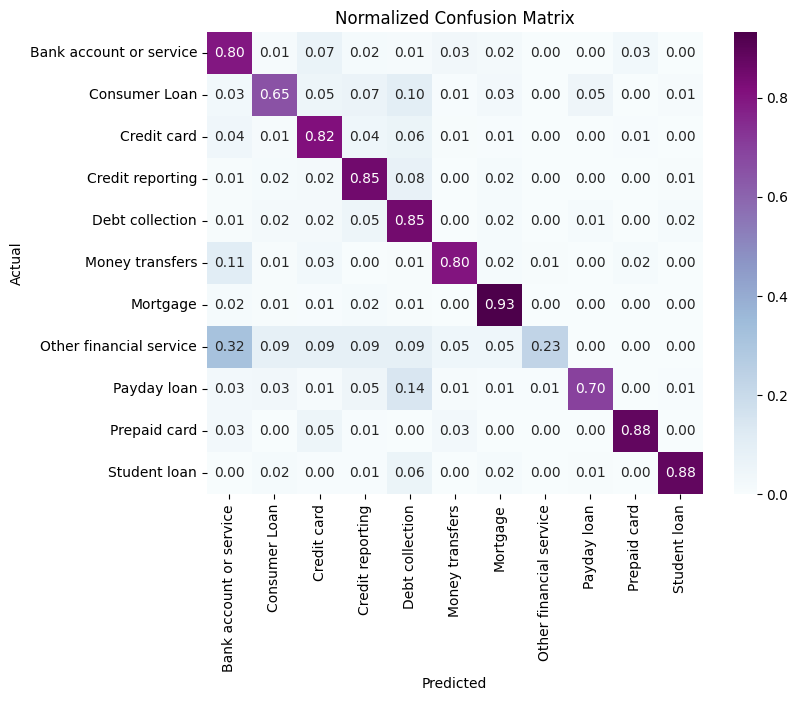

In [27]:
# Normalized confusion matrix to highlight minority classes
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(conf_mat/np.sum(conf_mat, axis=1)[:, None], annot=True, fmt='.2f', cmap="BuPu",
            xticklabels=category_id_df['product'].values,
            yticklabels=category_id_df['product'].values)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title("Normalized Confusion Matrix")
plt.show()


### Prediction example

In [28]:
texts = ["This company refuses to validate my debt."]  # new complaints
text_features = tfidf_vect.transform(texts)
pred_num = model.predict(text_features)  # numeric predictions
pred_label = encoder.inverse_transform(pred_num)  # convert numeric label to text
print(texts)
print(" - Predicted as: '{}'".format(pred_label[0]))

['This company refuses to validate my debt.']
 - Predicted as: 'Debt collection'


To increase the accuracy, we can do the following things:<br>
• Reiterate the process with different algorithms like
Random Forest, SVM, GBM, Neural Networks, Naive
Bayes.<br>
• Deep learning techniques like RNN and LSTM.
• In each of these algorithms, there are so many
parameters to be tuned to get better results.<br> It can be
easily done through Grid search, which will basically
try out all possible combinations and give the best out.

**Why Linear Models Were Chosen**
Linear models (Logistic Regression, Linear SVM) were selected over deep learning for this project due to:
- Faster inference and lower computational cost
- Strong baseline performance on keyword-heavy complaint text
- Easier interpretability for regulated environments

### Model Benchmarking

In [29]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
import pandas as pd

# Train additional models
nb_model = MultinomialNB()
nb_model.fit(xtrain_tfidf, train_y)
acc_nb = accuracy_score(valid_y, nb_model.predict(xvalid_tfidf))

svm_model = LinearSVC()
svm_model.fit(xtrain_tfidf, train_y)
acc_svm = accuracy_score(valid_y, svm_model.predict(xvalid_tfidf))

# Final comparison table
results_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Naive Bayes", "Linear SVM"],
    "Accuracy": [acc_lr, acc_nb, acc_svm]
})

results_df


,Model,Accuracy
0,Logistic Regression,0.845580
1,Naive Bayes,0.806366
2,Linear SVM,0.847103


In [30]:
from sklearn.metrics import f1_score
pred_nb = nb_model.predict(xvalid_tfidf)
pred_svm = svm_model.predict(xvalid_tfidf)

print("NB Weighted F1:", f1_score(valid_y, pred_nb, average='weighted'))
print("SVM Weighted F1:", f1_score(valid_y, pred_svm, average='weighted'))

NB Weighted F1: 0.7931153583526513
SVM Weighted F1: 0.8441993353126894


In [31]:
# Example: Top 5 features per category for Linear SVM
feature_names = tfidf_vect.get_feature_names_out()
for i, category in enumerate(encoder.classes_):
    top_features = sorted(
        zip(svm_model.coef_[i], feature_names),
        reverse=True
    )[:5]
    print(category, ":", [f[1] for f in top_features])

Bank account or service : ['scottrade', 'bank', 'branch', 'provisional', 'overdraft']
Consumer Loan : ['bmw', 'vehicle', 'acceptance', 'honda', 'toyota']
Credit card : ['barclaycard', 'barclay', 'balance transfer', 'discover', 'barclays']
Credit reporting : ['equifax', 'experian', 'transunion', 'trans union', 'report']
Debt collection : ['recovery', 'debt', 'collection', 'midland', 'afni']
Money transfers : ['moneygram', 'money transfer', 'transfer', 'google', 'western union']
Mortgage : ['mortgage', 'escrow', 'seterus', 'modification', 'loancare']
Other financial service : ['money order', 'budget', 'check', 'jp', 'law']
Payday loan : ['cash', 'payday', 'pay day', 'applied loan', 'loan']
Prepaid card : ['prepaid', 'rushcard', 'serve', 'netspend', 'card']
Student loan : ['navient', 'private', 'genesis', 'aes', 'graduated']


### Error Analysis
Understanding misclassifications helps identify overlapping product
definitions and ambiguous consumer language.


In [32]:
misclassified_idx = valid_y != model.predict(xvalid_tfidf)
valid_x[misclassified_idx].head(2)

264439    signed agreement debt collector dyck neal hand...
313645    account deleted xxxx <NUM> company entered acc...
Name: cleaned_complaint, dtype: object

### Robust Evaluation with Stratified Cross-Validation and Pipeline

To address class imbalance and ensure that model performance is not dependent
on a single train–test split, a Pipeline-based Logistic Regression model with
Stratified K-Fold Cross-Validation is used.

This approach:
- Prevents TF-IDF data leakage
- Preserves class distribution across folds
- Adjusts for minority classes using class-weight balancing


In [33]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression

# Pipeline = preprocessing + model (no leakage)
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1,2),
        max_features=7000,
        min_df=5
    )),
    ('clf', LogisticRegression(
        multi_class='ovr',
        solver='liblinear',
        class_weight='balanced',
        random_state=42
    ))
])

# Stratified K-Fold Cross-Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=skf,
    scoring='accuracy'
)

print(f"Stratified CV Accuracy: {cv_scores.mean():.3f} (+/- {cv_scores.std()*2:.3f})")

Stratified CV Accuracy: 0.846 (+/- 0.002)


In [34]:
cv_f1 = cross_val_score(
    pipeline,
    X,
    y,
    scoring='f1_weighted'
)

print(f"Weighted F1 (Stratified CV): {cv_f1.mean():.3f} (+/- {cv_f1.std()*2:.3f})")

Weighted F1 (Stratified CV): 0.843 (+/- 0.012)


- **Stratified CV Accuracy**: Shows the overall correctness of the model across folds.
- **Weighted F1 Score**: Accounts for class imbalance and provides a more reliable measure for minority classes.
- Using both ensures that our evaluation is robust and fair for all product categories.

### Model Explainability

In [35]:
feature_names = tfidf_vect.get_feature_names_out()
for i, category in enumerate(encoder.classes_):
    top_features = sorted(
        zip(model.coef_[i], feature_names),
        reverse=True
    )[:5]
    print(category, ":", [f[1] for f in top_features])

Bank account or service : ['bank', 'branch', 'scottrade', 'overdraft', 'account']
Consumer Loan : ['vehicle', 'car', 'financial', 'finance', 'loan']
Credit card : ['card', 'discover', 'credit card', 'citi', 'macy']
Credit reporting : ['equifax', 'experian', 'transunion', 'report', 'trans union']
Debt collection : ['debt', 'recovery', 'collection', 'owe', 'midland']
Money transfers : ['moneygram', 'transfer', 'paypal', 'money', 'google']
Mortgage : ['mortgage', 'modification', 'escrow', 'ocwen', 'home']
Other financial service : ['check', 'money order', 'creditor', 'nationwide', 'law']
Payday loan : ['cash', 'loan', 'payday', 'lender', 'pay day']
Prepaid card : ['prepaid', 'rushcard', 'card', 'netspend', 'money']
Student loan : ['navient', 'private', 'loan', 'aes', 'school']


### Business Use Case Mapping

- Automatically routes complaints to the correct internal team
- Reduces average handling time and operational cost
- Improves regulatory compliance through faster response
- Enables trend analysis for proactive risk management

### Save the model and artifacts

In [36]:
# Fit final pipeline on full training data
pipeline.fit(X, y)

# Save single deployable artifact
import joblib
joblib.dump(pipeline, "complaint_pipeline.pkl")
joblib.dump(encoder, "label_encoder.pkl")

['label_encoder.pkl']

In [37]:
# --- ADD THIS TO YOUR NOTEBOOK ---
import joblib

# 1. Create and save the SVM Pipeline
svm_pipeline = Pipeline([
    ('tfidf', tfidf_vect),
    ('clf', svm_model)
])
joblib.dump(svm_pipeline, "svm_pipeline.pkl")

# 2. Create and save the Naive Bayes Pipeline
nb_pipeline = Pipeline([
    ('tfidf', tfidf_vect),
    ('clf', nb_model)
])
joblib.dump(nb_pipeline, "nb_pipeline.pkl")

print("All 3 models (LR, SVM, NB) have been saved successfully!")

All 3 models (LR, SVM, NB) have been saved successfully!


### Final Model Selection

Logistic Regression with TF-IDF was selected for deployment due to:
- Comparable performance to Linear SVM
- Faster inference time
- Better interpretability for regulated environments